<a href="https://colab.research.google.com/github/ssurapaneni34/702project/blob/main/LSTM_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Complete pipeline: load → normalize → train → evaluate → export debate payloads**

Input : `patient_cards_v4.json`  
Output: `best_model.pt`, `debate_inputs.json`, `test_predictions.csv`, `model_config.json`

In [ ]:
!pip install -q scikit-learn joblib

from google.colab import drive
drive.mount('/content/drive')

import importlib
for pkg in ['torch', 'numpy', 'sklearn']:
    print(f'  {pkg:<12} {importlib.import_module(pkg).__version__}')
print('Ready ✓')

MessageError: Error: credential propagation was unsuccessful

## configuration

In [ ]:
import os, torch

# ── EDIT THESE ───────────────────────────────────────────────────────────────
CARDS_PATH  = '/content/drive/MyDrive/702 project/patient_cards_v2.json'
OUTPUT_DIR  = '/content/drive/MyDrive/702 project/lstm_outputs'   # saved model + predictions

# Model
HIDDEN_DIM   = 128
NUM_LAYERS   = 2
DROPOUT      = 0.3

# Training
BATCH_SIZE   = 64
EPOCHS       = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE     = 5      # early stopping patience (epochs without val F1 improvement)

# Split
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
# TEST = remainder (0.15)

TOP_K_DEBATE = 3      # top-K ICD candidates passed to debate agents
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'Output : {OUTPUT_DIR}')

Device : cuda
Output : /content/drive/MyDrive/702 project/lstm_outputs


##load patient cards

In [ ]:
import json, numpy as np

print(f'Loading {CARDS_PATH} …')
with open(CARDS_PATH) as f:
    data = json.load(f)

cards         = data['patients']
label_map     = data['label_map']          # {icd_code: int}
feature_names = data['feature_names']
n_features    = data['n_features']
n_timesteps   = data['n_timesteps']        # 12
num_classes   = len(label_map)
inv_label_map = {v: k for k, v in label_map.items()}

# Sanity check
c0  = cards[0]
ts0 = np.array(c0['time_series'])
assert ts0.shape == (n_timesteps, n_features), f'Shape mismatch: {ts0.shape}'
assert isinstance(c0['label'], int)
assert np.isfinite(ts0).all(), 'NaN/Inf in time_series'

print(f'Cards         : {len(cards):,}')
print(f'Classes       : {num_classes}')
print(f'Tensor shape  : ({n_timesteps}, {n_features}) per patient')
print('Sanity checks passed ✓')

Loading /content/drive/MyDrive/702 project/patient_cards_v2.json …
Cards         : 14,968
Classes       : 50
Tensor shape  : (12, 502) per patient
Sanity checks passed ✓


## patient-level train/val/test split

In [ ]:
import random
from collections import defaultdict, Counter

random.seed(42)
np.random.seed(42)

# Group by patient_id so the same patient never spans train + test
patient_to_cards = defaultdict(list)
for i, card in enumerate(cards):
    patient_to_cards[card['patient_id']].append(i)

patient_ids = list(patient_to_cards.keys())
random.shuffle(patient_ids)

n_train = int(len(patient_ids) * TRAIN_RATIO)
n_val   = int(len(patient_ids) * VAL_RATIO)

train_pids = set(patient_ids[:n_train])
val_pids   = set(patient_ids[n_train:n_train + n_val])
test_pids  = set(patient_ids[n_train + n_val:])

train_cards = [cards[i] for pid in train_pids for i in patient_to_cards[pid]]
val_cards   = [cards[i] for pid in val_pids   for i in patient_to_cards[pid]]
test_cards  = [cards[i] for pid in test_pids  for i in patient_to_cards[pid]]

print(f'Patients — train: {len(train_pids):,}  val: {len(val_pids):,}  test: {len(test_pids):,}')
print(f'Stays    — train: {len(train_cards):,}  val: {len(val_cards):,}  test: {len(test_cards):,}')

# Label distribution
train_counts = Counter(c['label'] for c in train_cards)
rarest  = min(train_counts, key=train_counts.get)
richest = max(train_counts, key=train_counts.get)
print(f'\nLabel imbalance — most: {inv_label_map[richest]} n={train_counts[richest]}  '
      f'rarest: {inv_label_map[rarest]} n={train_counts[rarest]}  '
      f'ratio: {train_counts[richest]/max(train_counts[rarest],1):.1f}x')

Patients — train: 8,381  val: 1,795  test: 1,797
Stays    — train: 10,485  val: 2,268  test: 2,215

Label imbalance — most: A419 n=2164  rarest: R079 n=1  ratio: 2164.0x


## feature normalization
Fit `StandardScaler` on training **value columns only** (even indices).  
Mask columns (odd indices, always 0/1) are left untouched.  
Scaler is saved to disk so the debate framework notebook can apply it at inference.

In [ ]:
# ── Feature scale diagnostic BEFORE normalisation ────────────────────────
X_raw = np.array([c['time_series'] for c in train_cards])  # (N, 12, F)

val_idx  = list(range(0, n_features, 2))   # even = value columns
mask_idx = list(range(1, n_features, 2))   # odd  = mask columns

print(f'Top-20 feature scales (observed values only):')
print(f"{'feature':<40} {'mean':>8} {'std':>8} {'max':>8}")
print('-' * 68)
for idx, fi in enumerate(val_idx[:20]):
    col   = X_raw[:, :, fi].flatten()
    obs   = col[col != 0]
    if len(obs) > 0:
        fname = feature_names[fi].replace('_val', '')
        print(f'  {fname:<38} {obs.mean():>8.2f} {obs.std():>8.2f} {obs.max():>8.2f}')

Top-20 feature scales (observed values only):
feature                                      mean      std      max
--------------------------------------------------------------------
  heart_rate                                84.61    40.89  7567.00
  respiratory_rate                          19.99     6.18   280.00
  o2_saturation_pulseoxymetry               95.28     6.72   993.00
  non_invasive_blood_pressure_systolic     118.01    20.48   249.00
  non_invasive_blood_pressure_diastolic     67.36   174.07 59112.00
  non_invasive_blood_pressure_mean          80.87    41.70  8321.00
  orientation                                1.00     0.00     1.00
  arterial_blood_pressure_mean              77.01   337.55 58141.00
  arterial_blood_pressure_systolic         112.53    25.51   217.00
  arterial_blood_pressure_diastolic         55.57    14.08   183.00
  activity_mobility                          2.84     1.52     8.00


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# Fit on training val columns — shape (N_train * T, F/2)
X_train_raw  = np.array([c['time_series'] for c in train_cards])
N_tr, T, F   = X_train_raw.shape
train_vals   = X_train_raw[:, :, val_idx].reshape(-1, len(val_idx))

scaler = StandardScaler()
scaler.fit(train_vals)

scaler_path = os.path.join(OUTPUT_DIR, 'feature_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'Scaler fitted on {N_tr:,} training stays and saved to {scaler_path}')

def normalise(cards_list, scaler, val_idx, mask_idx):
    """
    Apply fitted scaler to val columns only.
    Mask columns (0/1) are preserved exactly as-is.
    Returns float32 numpy array (N, T, F).
    """
    X     = np.array([c['time_series'] for c in cards_list], dtype=np.float32)
    N, T, F = X.shape
    vals_scaled = scaler.transform(
        X[:, :, val_idx].reshape(-1, len(val_idx))
    ).reshape(N, T, len(val_idx)).astype(np.float32)
    X[:, :, val_idx] = vals_scaled
    return X

X_train = normalise(train_cards, scaler, val_idx, mask_idx)
X_val   = normalise(val_cards,   scaler, val_idx, mask_idx)
X_test  = normalise(test_cards,  scaler, val_idx, mask_idx)

print(f'After scaling:')
print(f'  val cols  — mean: {X_train[:,:,val_idx].mean():.4f}  '
                      f'std: {X_train[:,:,val_idx].std():.4f}')
print(f'  mask cols — mean: {X_train[:,:,mask_idx].mean():.4f}  '
                      f'min: {X_train[:,:,mask_idx].min():.0f}  '
                      f'max: {X_train[:,:,mask_idx].max():.0f}')

Scaler fitted on 10,485 training stays and saved to /content/drive/MyDrive/702 project/lstm_outputs/feature_scaler.pkl
After scaling:
  val cols  — mean: -0.0000  std: 0.8374
  mask cols — mean: 0.0517  min: 0  max: 1


## dataset and data loader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):
    """Lean dataset — tensors only. clinical_summary accessed separately."""
    def __init__(self, X_norm, cards):
        self.X      = X_norm                              # (N, 12, F) float32
        self.labels = np.array([c['label'] for c in cards], dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'time_series': torch.from_numpy(self.X[idx]),          # (12, F)
            'label':       torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = ICUDataset(X_train, train_cards)
val_ds   = ICUDataset(X_val,   val_cards)
test_ds  = ICUDataset(X_test,  test_cards)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(device=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=='cuda'))

# Verify one batch
batch = next(iter(train_loader))
print(f'Batch time_series : {batch["time_series"].shape}  dtype={batch["time_series"].dtype}')
print(f'Batch label       : {batch["label"].shape}  dtype={batch["label"].dtype}')

Batch time_series : torch.Size([64, 12, 502])  dtype=torch.float32
Batch label       : torch.Size([64])  dtype=torch.int64


## model

In [ ]:
# import torch.nn as nn

# class ICU_LSTM(nn.Module):
#     """
#     LSTM classifier for ICD-10 multiclass prediction.
#     Input  : (B, T=12, F=n_features)  — normalised val+mask tensor
#     Output : (B, num_classes)          — raw logits
#     """
#     def __init__(self, input_dim, hidden_dim, num_layers,
#                  num_classes, dropout=0.3):
#         super().__init__()
#         # Linear projection: decouples input width from LSTM hidden size
#         self.input_proj = nn.Linear(input_dim, hidden_dim)
#         self.lstm = nn.LSTM(
#             input_size  = hidden_dim,
#             hidden_size = hidden_dim,
#             num_layers  = num_layers,
#             batch_first = True,
#             dropout     = dropout if num_layers > 1 else 0.0,
#         )
#         self.head = nn.Sequential(
#             nn.LayerNorm(hidden_dim),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim, num_classes),
#         )

#     def forward(self, x):
#         x = self.input_proj(x)            # (B, T, H)
#         _, (h_n, _) = self.lstm(x)        # h_n: (num_layers, B, H)
#         return self.head(h_n[-1])         # (B, num_classes)


# # ── Class weights (inverse frequency) ────────────────────────────────────
# label_counts = np.zeros(num_classes)
# for c in train_cards:
#     label_counts[c['label']] += 1
# label_counts = np.maximum(label_counts, 1)   # avoid divide-by-zero
# class_weights = torch.tensor(
#     len(train_cards) / (num_classes * label_counts),
#     dtype=torch.float32
# ).to(device)

# model    = ICU_LSTM(n_features, HIDDEN_DIM, NUM_LAYERS,
#                     num_classes, DROPOUT).to(device)
# loss_fn  = nn.CrossEntropyLoss(weight=class_weights)

# n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Parameters        : {n_params:,}')
# print(f'Input  → LSTM     : ({n_timesteps}, {n_features}) → hidden {HIDDEN_DIM}')
# print(f'Output classes    : {num_classes}')
# print(f'Class weight range: [{class_weights.min():.3f}, {class_weights.max():.3f}]')

Parameters        : 335,282
Input  → LSTM     : (12, 502) → hidden 128
Output classes    : 50
Class weight range: [0.097, 209.700]


In [ ]:
class ICU_LSTM(nn.Module):
    """
    Bidirectional LSTM classifier for ICD-10 multiclass prediction.
    Input  : (B, T=12, F=n_features)  — normalised val+mask tensor
    Output : (B, num_classes)          — raw logits
    """
    def __init__(self, input_dim, hidden_dim, num_layers,
                 num_classes, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.lstm = nn.LSTM(
            input_size  = hidden_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = True,               # ← added
        )
        # hidden state is now 2 * hidden_dim (forward + backward)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),        # ← was hidden_dim
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes),  # ← was hidden_dim
        )

    def forward(self, x):
        x = self.input_proj(x)                  # (B, T, H)
        _, (h_n, _) = self.lstm(x)              # h_n: (num_layers*2, B, H)
        # Concatenate the final forward and backward hidden states
        fwd = h_n[-2]                           # last forward layer
        bwd = h_n[-1]                           # last backward layer
        out = torch.cat([fwd, bwd], dim=-1)     # (B, H*2)
        return self.head(out)

## overfit sanity check
Confirms the model can learn from data before committing to a full training run.  
Loss should drop well below 2.0 within 100 steps.

In [ ]:
test_model = ICU_LSTM(n_features, HIDDEN_DIM, NUM_LAYERS,
                      num_classes, DROPOUT).to(device)
test_opt   = torch.optim.Adam(test_model.parameters(), lr=1e-3)
test_loss  = nn.CrossEntropyLoss()

one_batch  = next(iter(train_loader))
ts_b       = one_batch['time_series'].to(device)
lb_b       = one_batch['label'].to(device)

print('Overfit test — loss should drop steadily (target < 1.0 by step 80):')
for step in range(101):
    test_opt.zero_grad()
    loss = test_loss(test_model(ts_b), lb_b)
    loss.backward()
    test_opt.step()
    if step % 20 == 0:
        print(f'  step {step:3d}  loss={loss.item():.4f}')

del test_model, test_opt
if loss.item() > 3.0:
    print('WARNING: loss did not decrease — check data pipeline before full training')
else:
    print('Sanity check passed ✓ — proceed to full training')

Overfit test — loss should drop steadily (target < 1.0 by step 80):
  step   0  loss=4.2049
  step  20  loss=0.5433
  step  40  loss=0.0854
  step  60  loss=0.0345
  step  80  loss=0.0198
  step 100  loss=0.0136
Sanity check passed ✓ — proceed to full training


##TRAINing




In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score

optimizer  = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = ReduceLROnPlateau(optimizer, mode='max', patience=3,
                               factor=0.5)

best_val_f1    = 0.0
best_epoch     = 0
epochs_no_imp  = 0   # early stopping counter
history        = []  # for plotting

model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        ts     = batch['time_series'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        logits = model(ts)
        loss   = loss_fn(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for batch in val_loader:
            ts     = batch['time_series'].to(device)
            labels = batch['label'].to(device)
            logits = model(ts)
            val_preds.extend(logits.argmax(-1).cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_f1  = f1_score(val_labels_list, val_preds,
                       average='macro', zero_division=0)
    val_acc = np.mean(np.array(val_preds) == np.array(val_labels_list))
    scheduler.step(val_f1)

    history.append({
        'epoch': epoch, 'train_loss': avg_train_loss,
        'val_acc': val_acc, 'val_f1': val_f1
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save(model.state_dict(), model_path)
        flag = ' ← best'
    else:
        epochs_no_imp += 1

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'loss={avg_train_loss:.4f}  '
          f'val_acc={val_acc:.3f}  '
          f'val_f1={val_f1:.3f}{flag}')

    if epochs_no_imp >= PATIENCE:
        print(f'\nEarly stopping — no improvement for {PATIENCE} epochs.')
        break

print(f'\nBest val F1={best_val_f1:.3f} at epoch {best_epoch}')
model.load_state_dict(torch.load(model_path, map_location=device))
print('Best model loaded ✓')

Epoch 01/40  loss=3.6678  val_acc=0.173  val_f1=0.083 ← best
Epoch 02/40  loss=3.1503  val_acc=0.193  val_f1=0.113 ← best
Epoch 03/40  loss=2.8858  val_acc=0.190  val_f1=0.127 ← best
Epoch 04/40  loss=2.7832  val_acc=0.205  val_f1=0.121
Epoch 05/40  loss=2.5204  val_acc=0.205  val_f1=0.125
Epoch 06/40  loss=2.3985  val_acc=0.224  val_f1=0.134 ← best
Epoch 07/40  loss=2.2514  val_acc=0.190  val_f1=0.122
Epoch 08/40  loss=2.1087  val_acc=0.203  val_f1=0.117
Epoch 09/40  loss=1.9231  val_acc=0.201  val_f1=0.129
Epoch 10/40  loss=1.8545  val_acc=0.250  val_f1=0.138 ← best
Epoch 11/40  loss=1.7257  val_acc=0.219  val_f1=0.136
Epoch 12/40  loss=1.6071  val_acc=0.205  val_f1=0.131
Epoch 13/40  loss=1.5720  val_acc=0.209  val_f1=0.133
Epoch 14/40  loss=1.4481  val_acc=0.208  val_f1=0.129
Epoch 15/40  loss=1.2076  val_acc=0.210  val_f1=0.137

Early stopping — no improvement for 5 epochs.

Best val F1=0.138 at epoch 10
Best model loaded ✓


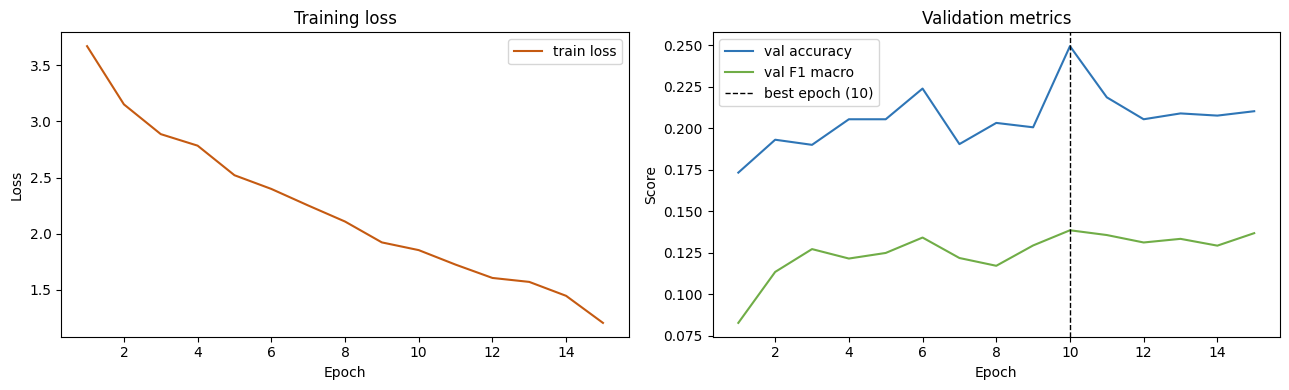

In [ ]:
import matplotlib.pyplot as plt

epochs_run = [h['epoch']      for h in history]
losses     = [h['train_loss'] for h in history]
val_accs   = [h['val_acc']    for h in history]
val_f1s    = [h['val_f1']     for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_run, losses, color='#C55A11', label='train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax1.legend()

ax2.plot(epochs_run, val_accs, color='#2E75B6', label='val accuracy')
ax2.plot(epochs_run, val_f1s,  color='#70AD47', label='val F1 macro')
ax2.axvline(best_epoch, color='black', linestyle='--',
            linewidth=1, label=f'best epoch ({best_epoch})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Validation metrics')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## evaluate on test set

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        ts     = batch['time_series'].to(device)
        labels = batch['label'].to(device)
        logits = model(ts)
        probs  = torch.softmax(logits, dim=-1)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)    # (N_test, num_classes)

# Headline metrics
top1_acc    = accuracy_score(all_labels, all_preds)
f1_macro    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Top-K accuracy
topk_acc = {}
for k in [3, 5]:
    topk_preds  = np.argsort(all_probs, axis=1)[:, -k:]
    topk_acc[k] = np.mean([all_labels[i] in topk_preds[i]
                            for i in range(len(all_labels))])

print('═' * 50)
print('TEST SET RESULTS')
print('═' * 50)
print(f'  Top-1 accuracy   : {top1_acc*100:6.2f}%')
print(f'  Top-3 accuracy   : {topk_acc[3]*100:6.2f}%')
print(f'  Top-5 accuracy   : {topk_acc[5]*100:6.2f}%')
print(f'  F1 macro         : {f1_macro*100:6.2f}%')
print(f'  F1 weighted      : {f1_weighted*100:6.2f}%')
print(f'  Test samples     : {len(all_labels):,}')

══════════════════════════════════════════════════
TEST SET RESULTS
══════════════════════════════════════════════════
  Top-1 accuracy   :  26.46%
  Top-3 accuracy   :  55.98%
  Top-5 accuracy   :  68.58%
  F1 macro         :  13.49%
  F1 weighted      :  25.25%
  Test samples     : 2,215


##Extract Top-K Predictions for Debate Agents

Iterates `test_cards` directly (not the DataLoader) so `clinical_summary`
is available per patient without collation issues.

In [ ]:
model.eval()
debate_inputs = []

with torch.no_grad():
    for card, x_norm in zip(test_cards, X_test):
        ts     = torch.from_numpy(x_norm).unsqueeze(0).to(device)  # (1, 12, F)
        logits = model(ts)
        probs  = torch.softmax(logits, dim=-1)
        topk   = torch.topk(probs, k=TOP_K_DEBATE, dim=-1)

        top_indices = topk.indices[0].tolist()
        top_probs   = topk.values[0].tolist()
        top_codes   = [inv_label_map[i] for i in top_indices]
        true_label  = card['label']
        true_code   = inv_label_map[true_label]

        debate_inputs.append({
            'visit_id':         card['visit_id'],
            'stay_id':          card.get('stay_id', ''),
            'lstm_prediction':  top_codes[0],
            'lstm_confidence':  round(top_probs[0], 4),
            'top_k_codes':      top_codes,
            'top_k_probs':      [round(p, 4) for p in top_probs],
            'top_k_indices':    top_indices,
            'true_label':       true_label,
            'true_icd_code':    true_code,
            'lstm_correct':     top_codes[0] == true_code,
            'true_in_topk':     true_code in top_codes,
            'clinical_summary': card.get('clinical_summary', {}),
        })

lstm_top1   = np.mean([d['lstm_correct'] for d in debate_inputs])
in_topk     = np.mean([d['true_in_topk'] for d in debate_inputs])
conf_corr   = np.mean([d['lstm_confidence'] for d in debate_inputs if d['lstm_correct']])
conf_wrong  = np.mean([d['lstm_confidence'] for d in debate_inputs if not d['lstm_correct']])

print(f'Payloads built         : {len(debate_inputs):,}')
print(f'LSTM top-1 accuracy    : {lstm_top1*100:.1f}%')
print(f'True label in top-{TOP_K_DEBATE}    : {in_topk*100:.1f}%  ← debate agent ceiling')
print(f'Avg confidence correct : {conf_corr:.3f}')
print(f'Avg confidence wrong   : {conf_wrong:.3f}')

# Sample hard case — wrong but true label is in top-K (best debate target)
import pprint
hard = [d for d in debate_inputs if not d['lstm_correct'] and d['true_in_topk']]
if hard:
    sample = hard[0]
    print(f'\nSample hard case:')
    print(f'  LSTM predicted : {sample["lstm_prediction"]} '
          f'(conf {sample["lstm_confidence"]:.3f})')
    print(f'  True label     : {sample["true_icd_code"]}')
    print(f'  Top-{TOP_K_DEBATE} candidates : {sample["top_k_codes"]} '
          f'{[round(p,3) for p in sample["top_k_probs"]]}')

Payloads built         : 2,215
LSTM top-1 accuracy    : 26.5%
True label in top-3    : 56.0%  ← debate agent ceiling
Avg confidence correct : 0.459
Avg confidence wrong   : 0.332

Sample hard case:
  LSTM predicted : I350 (conf 0.246)
  True label     : I2510
  Top-3 candidates : ['I350', 'I214', 'I2510'] [0.246, 0.212, 0.173]


## save all outputs

In [ ]:
import json
import pandas as pd

def to_python(obj):
    """Recursively convert numpy/torch types to plain Python for JSON."""
    if isinstance(obj, (np.integer,)):          return int(obj)
    if isinstance(obj, (np.floating,)):         return float(obj)
    if isinstance(obj, np.ndarray):             return obj.tolist()
    if isinstance(obj, torch.Tensor):           return obj.tolist()
    if isinstance(obj, dict):  return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [to_python(v) for v in obj]
    return obj

# ── 1. Debate inputs JSON ─────────────────────────────────────────────────
debate_path = os.path.join(OUTPUT_DIR, 'debate_inputs.json')
with open(debate_path, 'w') as f:
    json.dump({
        'label_map':         label_map,
        'inv_label_map':     {str(k): v for k, v in inv_label_map.items()},
        'top_k':             TOP_K_DEBATE,
        'n_test':            len(debate_inputs),
        'lstm_top1_acc':     round(float(lstm_top1), 4),
        'true_in_topk_rate': round(float(in_topk),   4),
        'patients':          to_python(debate_inputs),
    }, f, indent=2)

# ── 2. Test predictions CSV ───────────────────────────────────────────────
csv_path = os.path.join(OUTPUT_DIR, 'test_predictions.csv')
pd.DataFrame([{
    'visit_id':     d['visit_id'],
    'stay_id':      d['stay_id'],
    'true_icd':     d['true_icd_code'],
    'pred_icd':     d['lstm_prediction'],
    'confidence':   d['lstm_confidence'],
    'correct':      d['lstm_correct'],
    'true_in_topk': d['true_in_topk'],
    'top_k_codes':  ' | '.join(d['top_k_codes']),
    'top_k_probs':  ' | '.join(f"{p:.3f}" for p in d['top_k_probs']),
} for d in debate_inputs]).to_csv(csv_path, index=False)

# ── 3. Model config (architecture params for reloading) ───────────────────
config_path = os.path.join(OUTPUT_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump({
        'input_dim':    n_features,
        'hidden_dim':   HIDDEN_DIM,
        'num_layers':   NUM_LAYERS,
        'num_classes':  num_classes,
        'dropout':      DROPOUT,
        'n_timesteps':  n_timesteps,
        'label_map':    label_map,
        'feature_names': feature_names,
    }, f, indent=2)

# ── Summary ───────────────────────────────────────────────────────────────
print('Saved outputs:')
for path in [model_path, debate_path, csv_path, config_path, scaler_path]:
    mb = os.path.getsize(path) / 1e6
    print(f'  {os.path.basename(path):<30} {mb:.2f} MB')

print(f'\nDebate agent ceiling (true in top-{TOP_K_DEBATE}): {in_topk*100:.1f}%')
print(f'Best val F1 achieved : {best_val_f1*100:.2f}%  (epoch {best_epoch})')

Saved outputs:
  best_model.pt                  1.35 MB
  debate_inputs.json             20.80 MB
  test_predictions.csv           0.20 MB
  model_config.json              0.01 MB
  feature_scaler.pkl             0.01 MB

Debate agent ceiling (true in top-3): 56.0%
Best val F1 achieved : 13.85%  (epoch 10)


check reload

In [ ]:
# ── Reload verification — use this pattern in the debate framework notebook ─
with open(config_path) as f:
    cfg = json.load(f)

reloaded = ICU_LSTM(
    input_dim   = cfg['input_dim'],
    hidden_dim  = cfg['hidden_dim'],
    num_layers  = cfg['num_layers'],
    num_classes = cfg['num_classes'],
    dropout     = cfg['dropout'],
).to(device)
reloaded.load_state_dict(torch.load(model_path, map_location=device))
reloaded.eval()

dummy = torch.zeros(1, cfg['n_timesteps'], cfg['input_dim']).to(device)
with torch.no_grad():
    out = reloaded(dummy)
assert out.shape == (1, cfg['num_classes'])
print(f'Model reloads cleanly ✓  output: {tuple(out.shape)}')

Model reloads cleanly ✓  output: (1, 50)
